In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import accuracy_score, log_loss
from tqdm import tqdm

In [83]:
class Neural_Network:
    

    def __init__(self, n1=128, learning_rate=0.01, n_iter=3000):
        self.n1 = n1
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.parametres = {}
        self.train_loss = []
        self.train_acc = []
        self.history = []

    def fit(self, X, y):
        
        n0 = X.shape[0]
        n2 = y.shape[0]
        np.random.seed(0)
        self._initialisation(n0, self.n1, n2)
        self.train_loss = []
        self.train_acc = []
        self.history = []

        for i in tqdm(range(self.n_iter)):
            activations = self._forward_propagation(X)
            A2 = activations['A2']

            self.train_loss.append(log_loss(y.flatten(), A2.flatten()))
            y_pred = self.predict(X)
            self.train_acc.append(accuracy_score(y.flatten(), y_pred.flatten()))
            self.history.append([self.parametres.copy(), i])

            gradients = self._back_propagation(X, y, activations)
            self._update(gradients)

        self._plot()
        return self

    def predict(self, X):
        activations = self._forward_propagation(X)
        return (activations['A2'] >= 0.5).astype(int)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y.flatten(), y_pred.flatten())

    def _initialisation(self, n0, n1, n2):
        self.parametres = {
            'W1': np.random.randn(n1, n0),
            'b1': np.zeros((n1, 1)),
            'W2': np.random.randn(n2, n1),
            'b2': np.zeros((n2, 1)),
        }

    def _forward_propagation(self, X):
        W1, b1 = self.parametres['W1'], self.parametres['b1']
        W2, b2 = self.parametres['W2'], self.parametres['b2']

        A1 = 1 / (1 + np.exp(-(W1.dot(X) + b1)))
        A2 = 1 / (1 + np.exp(-(W2.dot(A1) + b2)))

        return {'A1': A1, 'A2': A2}

    def _back_propagation(self, X, y, activations):
        A1, A2 = activations['A1'], activations['A2']
        W2 = self.parametres['W2']
        m = y.shape[1]

        dZ2 = A2 - y
        dW2 = 1 / m * dZ2.dot(A1.T)
        db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

        dZ1 = W2.T.dot(dZ2) * A1 * (1 - A1)
        dW1 = 1 / m * dZ1.dot(X.T)
        db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

    def _update(self, gradients):
        for key in ['W1', 'b1', 'W2', 'b2']:
            self.parametres[key] -= self.learning_rate * gradients[f'd{key}']

    def _plot(self):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.train_loss, label='train loss')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(self.train_acc, label='train acc')
        plt.legend()
        plt.show()


dimensions de X: (2, 100)
dimensions de y: (1, 100)


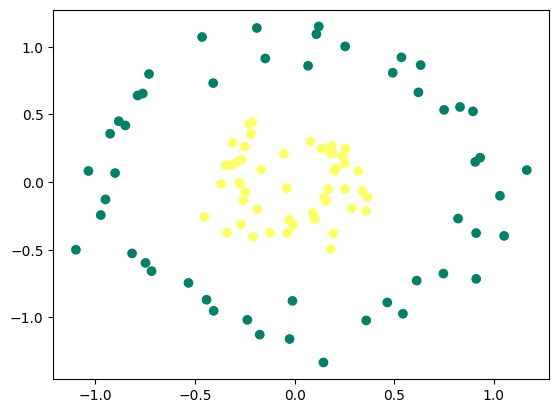

In [84]:
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[0, :], X[1, :], c=y, cmap='summer')
plt.show()

In [85]:
network = Neural_Network(n1=64, n_iter=2000)

  1%|▏         | 27/2000 [00:00<00:07, 266.96it/s]

100%|██████████| 2000/2000 [00:05<00:00, 398.90it/s]


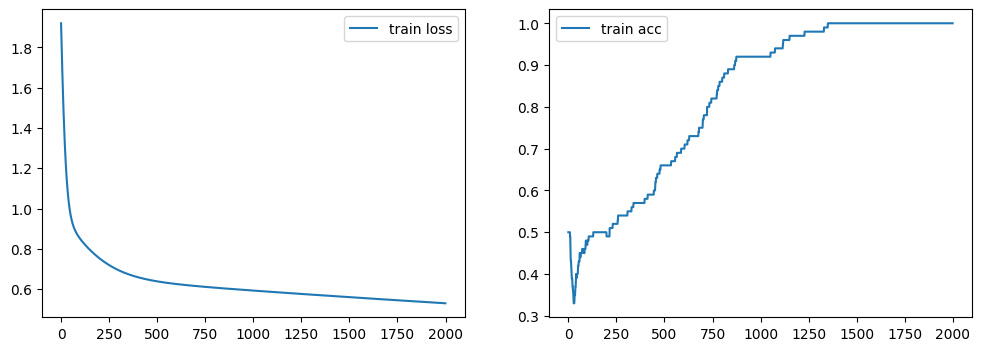

In [86]:
network.fit(X,y)

In [93]:
class DeepNeuralNetwork:

    def __init__(self, hidden_layers=(16, 16, 16), learning_rate=0.001, n_iter=3000):
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.parametres = {}
        self.training_history = None

    def fit(self, X, y):
        dimensions = list(self.hidden_layers)
        dimensions.insert(0, X.shape[0])
        dimensions.append(y.shape[0])
        np.random.seed(1)
        self.parametres = self._initialisation(dimensions)

        C = len(self.parametres) // 2
        self.training_history = np.zeros((self.n_iter, 2))

        for i in tqdm(range(self.n_iter)):
            activations = self._forward_propagation(X)
            gradients = self._back_propagation(y, activations)
            self._update(gradients)
            Af = activations['A' + str(C)]
            self.training_history[i, 0] = log_loss(y.flatten(), Af.flatten())
            y_pred = self.predict(X)
            self.training_history[i, 1] = accuracy_score(y.flatten(), y_pred.flatten())

        self._plot()
        return self

    def predict(self, X):
        activations = self._forward_propagation(X)
        C = len(self.parametres) // 2
        return (activations['A' + str(C)] >= 0.5).astype(int)

    def score(self, X, y):
        return accuracy_score(y.flatten(), self.predict(X).flatten())

    def _initialisation(self, dimensions):
        parametres = {}
        for c in range(1, len(dimensions)):
            parametres['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c - 1])
            parametres['b' + str(c)] = np.random.randn(dimensions[c], 1)
        return parametres

    def _forward_propagation(self, X):
        activations = {'A0': X}
        C = len(self.parametres) // 2
        for c in range(1, C + 1):
            Z = self.parametres['W' + str(c)].dot(activations['A' + str(c - 1)]) + self.parametres['b' + str(c)]
            activations['A' + str(c)] = 1 / (1 + np.exp(-Z))
        return activations

    def _back_propagation(self, y, activations):
        m = y.shape[1]
        C = len(self.parametres) // 2
        dZ = activations['A' + str(C)] - y
        gradients = {}
        for c in reversed(range(1, C + 1)):
            gradients['dW' + str(c)] = 1/m * np.dot(dZ, activations['A' + str(c - 1)].T)
            gradients['db' + str(c)] = 1/m * np.sum(dZ, axis=1, keepdims=True)
            if c > 1:
                dZ = np.dot(self.parametres['W' + str(c)].T, dZ) * activations['A' + str(c - 1)] * (1 - activations['A' + str(c - 1)])
        return gradients

    def _update(self, gradients):
        C = len(self.parametres) // 2
        for c in range(1, C + 1):
            self.parametres['W' + str(c)] -= self.learning_rate * gradients['dW' + str(c)]
            self.parametres['b' + str(c)] -= self.learning_rate * gradients['db' + str(c)]

    def _plot(self):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.training_history[:, 0], label='train loss')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(self.training_history[:, 1], label='train acc')
        plt.legend()
        plt.show()


100%|██████████| 3000/3000 [00:08<00:00, 361.63it/s]


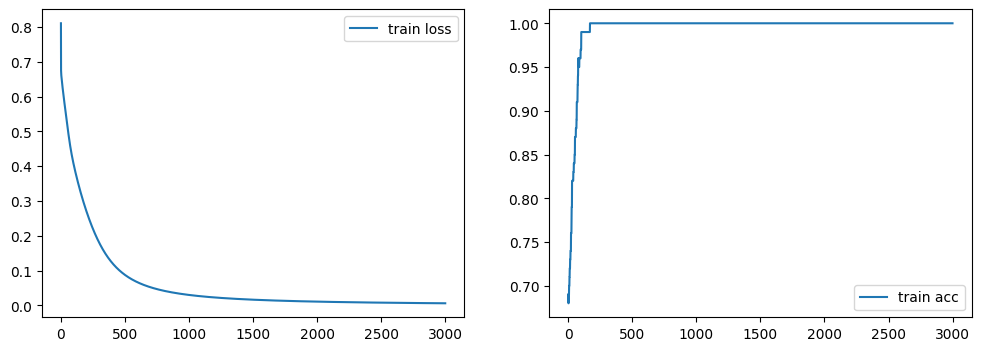

In [94]:
model = DeepNeuralNetwork(hidden_layers=(32, 32, 32), learning_rate=0.1, n_iter=3000)
model.fit(X, y)
